# 🍷 Wine Quality Prediction
**Course:** DX601 — Mathematical Foundations of Data Science 
**Program:** M.S. in Data Science, Boston University 
**Dataset:** UCI Wine Quality (White Wine) — 4,898 records, 11 features 

---

This project applies statistical analysis and machine learning to predict white wine quality ratings based on chemical properties. Analysis includes distribution modeling, feature correlation, linear regression, PCA, and outlier detection.

**Key Results:**
- Multi-feature OLS regression achieved **MSE of 0.5631**
- **Alcohol content** identified as strongest single predictor (MSE: 0.6354)
- First half of PCA components explain **~72.8%** of total variance
- **Residual sugar & density** identified as most correlated pair (r = 0.839)
- Outlier detected at row 2781 — residual sugar of **65.8** (typical range: 1–15)


In [1]:
import math
import sys

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

from sklearn.decomposition import PCA

## 1. Data Loading & Exploration


In [3]:
# YOUR CODE HERE

# Load the Wine Quality dataset (white subset)
df_wine = pd.read_csv("wine_quality_white.tsv.gz", sep="\t")

# Display a random sample of 10 rows to verify the data loaded correctly
df_wine.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
3426,7.1,0.17,0.40,14.55,0.047,47.0,156.0,0.99945,3.34,0.78,9.1,6
3907,6.7,0.31,0.30,2.40,0.038,30.0,83.0,0.98867,3.09,0.36,12.8,7
2375,7.0,0.32,0.29,4.90,0.036,41.0,150.0,0.99168,3.38,0.43,12.2,6
1261,7.3,0.19,0.68,1.50,0.050,31.0,156.0,0.99460,3.32,0.64,9.4,6
27,7.0,0.28,0.39,8.70,0.051,32.0,141.0,0.99610,3.38,0.53,10.5,6
4296,6.9,0.22,0.32,5.80,0.041,20.0,119.0,0.99296,3.17,0.55,11.2,6
2970,8.4,0.31,0.31,0.95,0.021,52.0,148.0,0.99038,2.93,0.32,11.5,5
1361,6.0,0.13,0.28,5.70,0.038,56.0,189.5,0.99480,3.59,0.43,10.6,7
1029,6.3,0.60,0.44,11.00,0.050,50.0,245.0,0.99720,3.19,0.57,9.3,4
81,7.1,0.20,0.34,16.00,0.050,51.0,166.0,0.99850,3.21,0.60,9.2,6


## 2. Feature Descriptions


In [4]:
# YOUR CODE HERE
# Display all column names in the dataset
df_wine.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'target'],
      dtype='str')

fixed acidity: measures the acids that stay in the wine, do not evaporate and affect the taste of the wine
volatile acidity: measures the acids that evaporate easily and affect the smell of the wine
citric acid: type of acid that makes the wine taste fresher
residual sugar: sugar that remains post-fermentation
chlorides: amount of salt in the wine
free sulfur dioxide: amount of sulfur dioxide that helps protect the wine from spoilage
total sulfur dioxide: total amount of sulfur dioxide present in the wine
density: how heavy the wine is compared to water
pH: measures how acidic the wine is
sulphates: compounds that help preserve the wine and can affect its taste
alcohol: amount of alcohol in the wine
target: the quality rating of the wine

## 3. Distribution Analysis


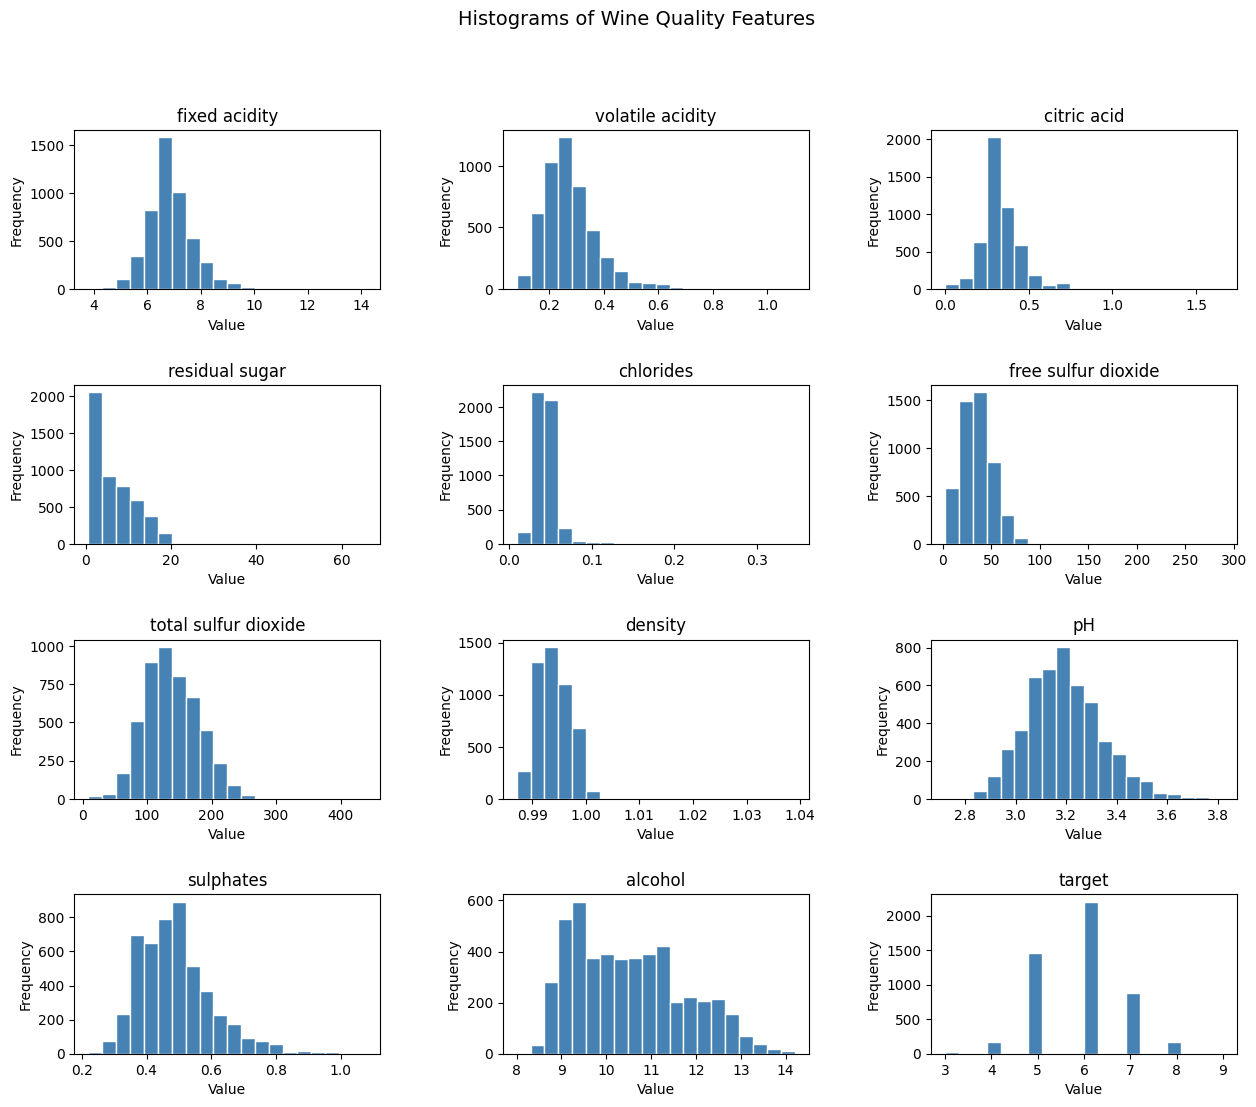

In [5]:
# YOUR CODE HERE
# Plot histograms for all columns to examine their distributions
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
plt.subplots_adjust(hspace=0.6, wspace=0.4)

for ax, col in zip(axes.flatten(), df_wine.columns):
    ax.hist(df_wine[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.suptitle("Histograms of Wine Quality Features", fontsize=14)
plt.show()

fixed acidity — roughly bell-shaped with a slight right skew, centered around 6 to 7.
volatile acidity — right-skewed, most values concentrated below 0.4.
citric acid — right-skewed with most values clustered near 0.
residual sugar — strongly right-skewed, with most wines having low sugar and a few outliers with very high values.
chlorides — strongly right-skewed, concentrated at very low values with a long tail.
free sulfur dioxide — right-skewed, most values fall below 100.
total sulfur dioxide — right-skewed, centered around 100 to 200.
density — roughly bell-shaped, tightly concentrated around 1.00.
pH — bell-shaped and fairly symmetric, centered around 3.1 to 3.3.
sulphates — right-skewed, most values between 0.3 and 0.6.
alcohol — slightly right-skewed, ranging mostly from 8 to 13.
target — discrete distribution, most wines rated 5 or 6, with very few at the extremes.

## 4. Feature Independence Analysis


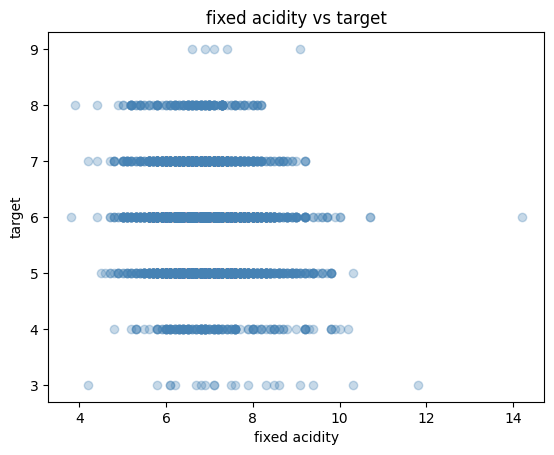

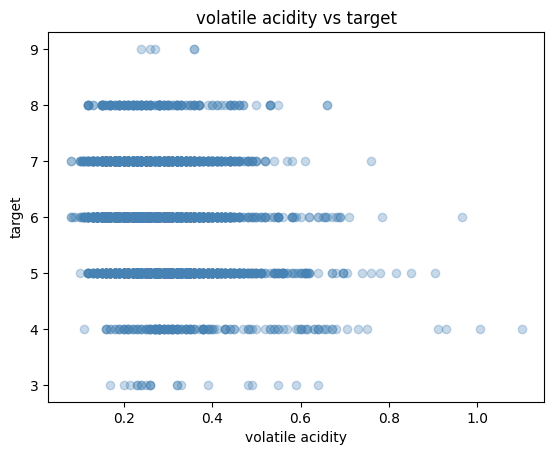

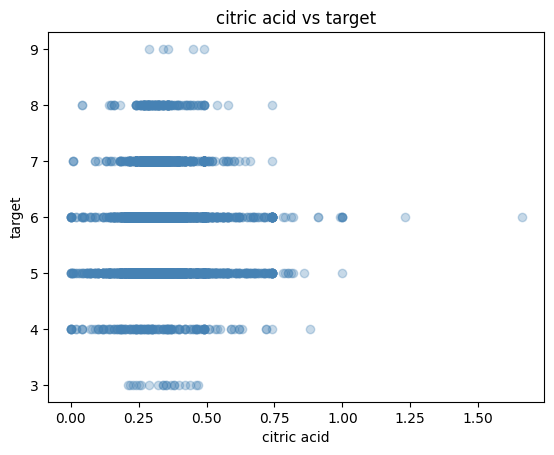

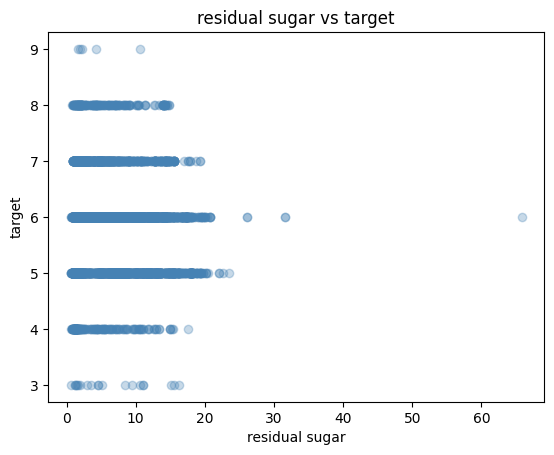

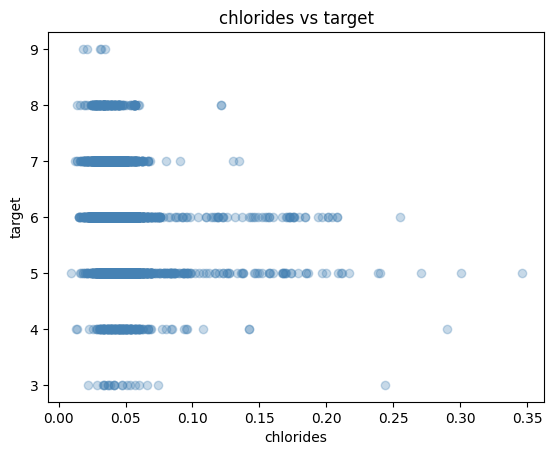

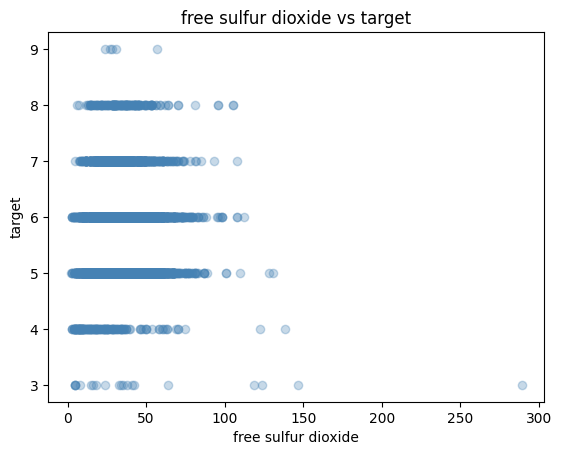

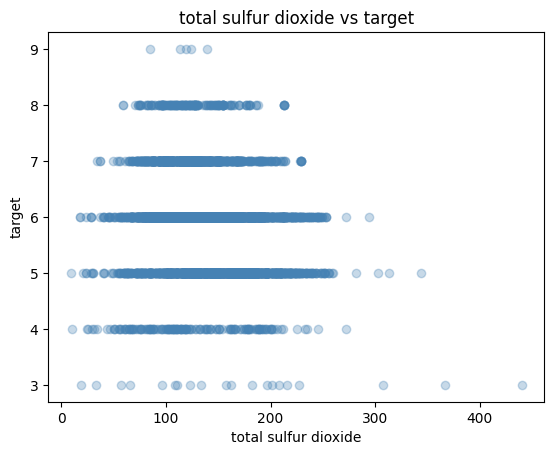

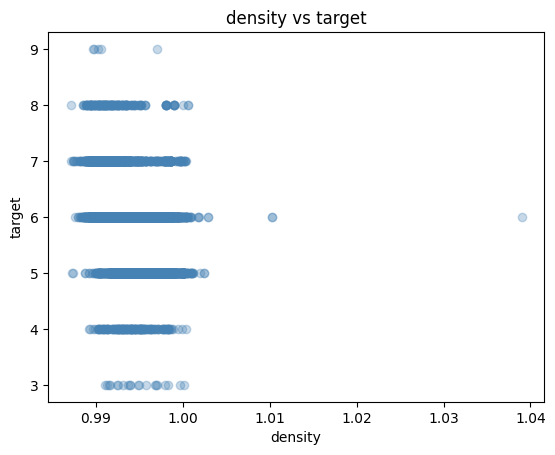

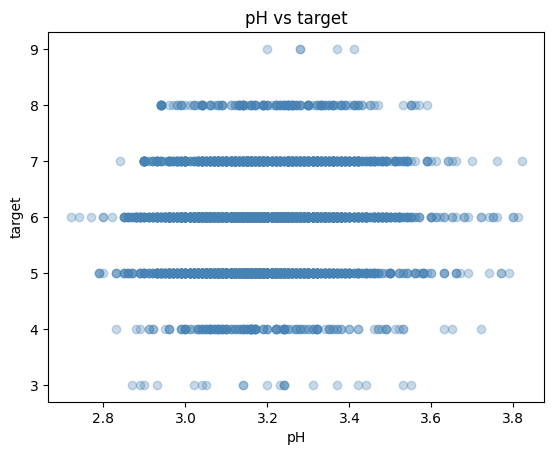

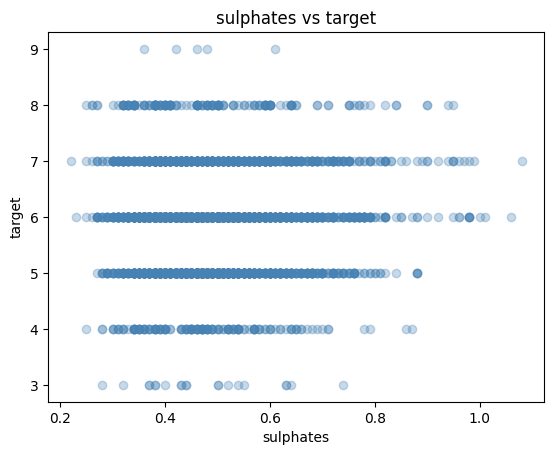

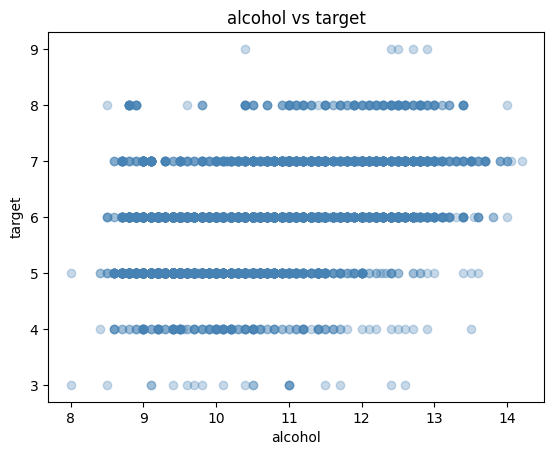

In [6]:
# YOUR CODE HERE
# Plot each input column against the target to assess independence
for col in df_wine.columns:
    if col != "target":
        plt.scatter(df_wine[col], df_wine["target"], alpha=0.3, color='steelblue')
        plt.xlabel(col)
        plt.ylabel("target")
        plt.title(f"{col} vs target")
        plt.show()

fixed acidity vs target: as fixed acidity increases, the target values remain spread across all levels with no clear pattern, so they are independent

volatile acidity vs target: as volatile acidity increases, higher target values become less common, showing a negative relationship so they are not independent

citric acid vs target: as citric acid increases, the target values remain spread across all levels with no clear pattern, so it seems independent

residual sugar vs target: the values are spread across all target levels with no clear pattern, so it seems independent

chlorides vs target: as chlorides increase, higher target values become less common, showing a negative relationship so it is not independent

free sulfur dioxide vs target: has a weak relationship, the target values are spread across the range with no clear strong pattern so its independent 

total sulfur dioxide vs target: as total sulfur dioxide increases, higher target values become less common, showing a weak negative relationship so it is not independent

density vs target: as density increases, the target values remain spread across all levels with no clear change, so it is independent

pH vs target: the target values are spread across all levels with no clear pattern or trend, so it seems independent

sulphates vs target: as sulphates increase, higher target values become more common, showing a positive relationship so it is not independent

alcohol vs target: as alcohol increases, lower target values become less common and higher values appear more often, showing a positive relationship so it is not independent

## 5. Linear Regression — All Features


Mean Squared Error: 0.5631540629886568


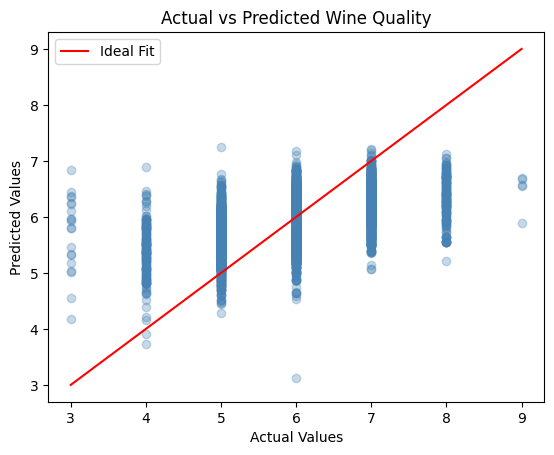

In [7]:
# YOUR CODE HERE

from sklearn.linear_model import LinearRegression

# Separate features and target variable
X = df_wine.drop(columns=["target"])
y = df_wine["target"]

# Train the linear regression model on all input columns
model = LinearRegression()
model.fit(X, y)

# Generate predictions
y_pred = model.predict(X)

# Calculate and report mean squared error
mse = np.mean((y - y_pred)**2)
print("Mean Squared Error:", mse)

# Plot actual vs predicted values

plt.scatter(y, y_pred, alpha=0.3, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', label="Ideal Fit")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Wine Quality")
plt.legend()
plt.show()

A linear regression model was trained using all input columns to predict wine quality. The model got a Mean Squared Error of 0.5631, which means predictions are roughly 0.75 quality points away from the actual values on average. The scatter plot shows that most predictions fall between 5 and 6, while actual values range from 3 to 9. This means the model does a reasonable job for average quality wines but struggles with wines that are very low or very high in quality. This is likely because a simple linear model cannot fully capture all the complex factors that affect wine quality.

## 6. Best Single-Feature Model


In [8]:
# YOUR CODE HERE

# Store MSE results for each individual column
mse_results = []

for col in df_wine.drop(columns=["target"]).columns:
    
    # Use one column at a time as the feature
    X = df_wine[[col]]
    
    # Train the model
    model = LinearRegression()
    model.fit(X, y)
    
    # Generate predictions and calculate MSE
    y_pred = model.predict(X)
    mse = np.mean((y - y_pred)**2)
    
    mse_results.append((col, mse))

# Display all MSE values per column
print(mse_results)

# Identify the column with the lowest MSE
best_col = min(mse_results, key=lambda x: x[1])
print("Best single column:", best_col)





[('fixed acidity', np.float64(0.7740643377514038)), ('volatile acidity', np.float64(0.7544611777913112)), ('citric acid', np.float64(0.7841290419696332)), ('residual sugar', np.float64(0.7767290354362435)), ('chlorides', np.float64(0.7496341230508563)), ('free sulfur dioxide', np.float64(0.7841433561228633)), ('total sulfur dioxide', np.float64(0.760251630201277)), ('density', np.float64(0.7102265148403777)), ('pH', np.float64(0.776443165059832)), ('sulphates', np.float64(0.7819360335229564)), ('alcohol', np.float64(0.6354137863260801))]
Best single column: ('alcohol', np.float64(0.6354137863260801))


The best single column for predicting wine quality was alcohol, with a Mean Squared Error of 0.6354. This is higher than the 0.5631 MSE from Problem 5, which used all columns. This makes sense because using more features gives the model more information to learn from, so it does a better job. When only one column is used, the model is missing a lot of useful information, which leads to less accurate predictions.

## 7. Feature Dependency & Threshold Split


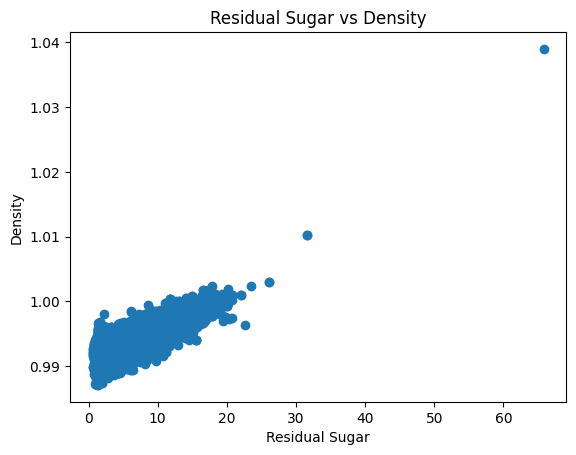

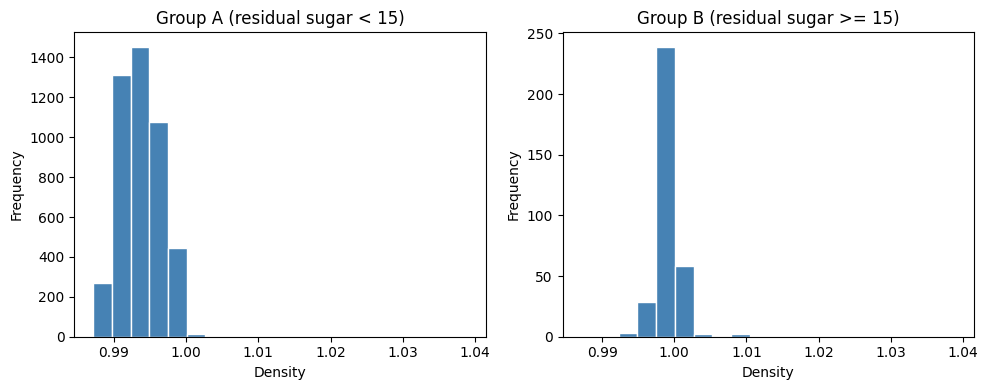

In [9]:
# YOUR CODE HERE
# Explore dependency between residual sugar and density
plt.scatter(df_wine["residual sugar"], df_wine["density"])
plt.xlabel("Residual Sugar")
plt.ylabel("Density")
plt.title("Residual Sugar vs Density")
plt.show()

# Set split threshold
t = 15

# Split data based on residual sugar threshold
low_sugar  = df_wine[df_wine["residual sugar"] < t]["density"]
high_sugar = df_wine[df_wine["residual sugar"] >= t]["density"]

# Use consistent x-axis range across both histograms
min_t = df_wine["density"].min()
max_t = df_wine["density"].max()

plt.figure(figsize=(10, 4))

# Group A: low residual sugar
plt.subplot(1, 2, 1)
plt.hist(low_sugar, bins=20, range=(min_t, max_t), color='steelblue', edgecolor='white')
plt.title("Group A (residual sugar < 15)")
plt.xlabel("Density")
plt.ylabel("Frequency")

# Group B: high residual sugar
plt.subplot(1, 2, 2)
plt.hist(high_sugar, bins=20, range=(min_t, max_t), color='steelblue', edgecolor='white')
plt.title("Group B (residual sugar >= 15)")
plt.xlabel("Density")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Residual sugar and density were chosen because the scatter plot shows a clear positive relationship between them. As residual sugar increases, density also increases. A threshold of 15 was used to split the data into two groups. Group A contains wines with low residual sugar, where density is tightly concentrated around 0.99 to 1.00. Group B contains wines with high residual sugar, where density shifts higher and spreads more toward 1.00 to 1.01. The two histograms look clearly different, which confirms that residual sugar and density are not independent.

## 8. Principal Component Analysis (PCA)


Variance explained by first half of components: 0.7282747359911348
MSE (PCA model): 0.6447665228603195
MSE (original model): 0.5631540629886564


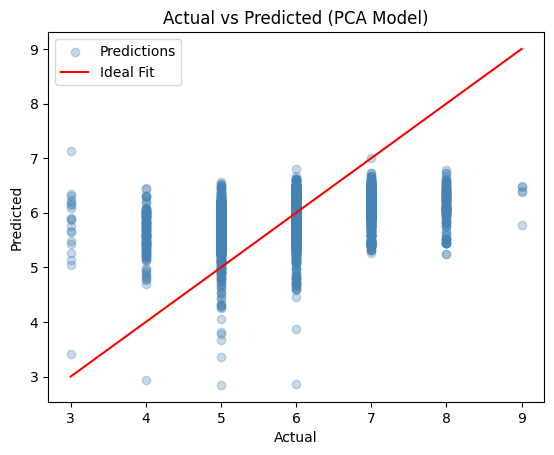

In [10]:
# YOUR CODE HERE

# Separate features (X) and target (y)

X = df_wine.drop(columns=["target"])
y = df_wine["target"]

# Compute mean and standard deviation for each feature
X_mean = X.mean()
X_std  = X.std()

# Manually scale the data
X_scaled = (X - X_mean) / X_std

# Create PCA model and transform scaled data into principal components
pca   = PCA()
X_pca = pca.fit_transform(X_scaled)

# Get explained variance ratio for each principal component
pca_ratio = pca.explained_variance_ratio_

# Select first half of the components
k = len(pca_ratio) // 2

# Compute fraction of total variance explained by first half of PCs
first_half = pca_ratio[:k].sum()
print("Variance explained by first half of components:", first_half)

# Keep only the first k principal components (dimensionality reduction)
Z_reduced = X_pca[:, :k]

# Train linear regression model using reduced PCA features
model_pca = sklearn.linear_model.LinearRegression()
model_pca.fit(Z_reduced, y)

# Predict target values using PCA based model
y_pred_pca = model_pca.predict(Z_reduced)

# Compute Mean Squared Error for PCA model
mse_pca = np.mean((y - y_pred_pca)**2)
print("MSE (PCA model):", mse_pca)

# Train linear regression model using all original scaled features
model_full = sklearn.linear_model.LinearRegression()
model_full.fit(X_scaled, y)

# Predict using full feature model
y_pred_full = model_full.predict(X_scaled)

# Compute MSE for full model
mse_full = np.mean((y - y_pred_full)**2)
print("MSE (original model):", mse_full)

# Plot actual vs predicted values for PCA model
plt.scatter(y, y_pred_pca, alpha=0.3, color='steelblue', label="Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()],
         color='red', linewidth=1.5, label="Ideal Fit")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (PCA Model)")
plt.legend()
plt.show()

PCA was applied to the scaled input features. The first half of the principal components explained approximately 72.8% of the total variance, meaning most of the useful information in the data is kept even after reducing the number of features.
A linear regression model trained on these reduced components produced an MSE of 0.644, while the model using all original features produced an MSE of 0.563. The PCA model performed slightly worse, which makes sense because some information was removed during dimensionality reduction. However, the difference is small, which shows that the first half of the components still captured most of the useful patterns in the data.

## 9. Highest Correlated Features & PCA Reflection


In [11]:
# YOUR CODE HERE
# Correlation matrix (to find most correlated pair)
X.corr()

# Compute correlation matrix to find the most correlated pair of input columns
X_corr = X.corr()
X_corr



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
fixed acidity,1.000000,-0.022697,0.289181,0.089021,0.023086,-0.049396,0.091070,0.265331,-0.425858,-0.017143,-0.120881
volatile acidity,-0.022697,1.000000,-0.149472,0.064286,0.070512,-0.097012,0.089261,0.027114,-0.031915,-0.035728,0.067718
citric acid,0.289181,-0.149472,1.000000,0.094212,0.114364,0.094077,0.121131,0.149503,-0.163748,0.062331,-0.075729
residual sugar,0.089021,0.064286,0.094212,1.000000,0.088685,0.299098,0.401439,0.838966,-0.194133,-0.026664,-0.450631
chlorides,0.023086,0.070512,0.114364,0.088685,1.000000,0.101392,0.198910,0.257211,-0.090439,0.016763,-0.360189
free sulfur dioxide,-0.049396,-0.097012,0.094077,0.299098,0.101392,1.000000,0.615501,0.294210,-0.000618,0.059217,-0.250104
total sulfur dioxide,0.091070,0.089261,0.121131,0.401439,0.198910,0.615501,1.000000,0.529881,0.002321,0.134562,-0.448892
density,0.265331,0.027114,0.149503,0.838966,0.257211,0.294210,0.529881,1.000000,-0.093591,0.074493,-0.780138
pH,-0.425858,-0.031915,-0.163748,-0.194133,-0.090439,-0.000618,0.002321,-0.093591,1.000000,0.155951,0.121432
sulphates,-0.017143,-0.035728,0.062331,-0.026664,0.016763,0.059217,0.134562,0.074493,0.155951,1.000000,-0.017433


In [12]:
# Display PCA components to see how correlation is reflected
pd.DataFrame(pca.components_, columns=X.columns)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.157218,0.005089,0.144050,0.427408,0.212011,0.300334,0.406652,0.511524,-0.128832,0.043379,-0.437238
1,0.587558,-0.051728,0.345295,-0.008749,0.008800,-0.290355,-0.244032,-0.006297,-0.581344,-0.222695,0.035569
2,-0.121368,0.590971,-0.504397,0.214320,0.102367,-0.279410,-0.124375,0.129203,-0.126672,-0.433244,-0.105903
3,0.018584,0.274115,0.148514,-0.273765,0.710712,-0.305585,-0.060456,-0.022061,0.097753,0.442060,-0.141079
4,0.251048,0.642617,0.053905,0.011391,-0.328628,0.176912,0.293010,-0.084588,-0.119826,0.400585,0.337419
5,-0.103531,0.122338,0.132097,-0.289447,0.395821,0.494494,0.276320,-0.327651,-0.193341,-0.481039,0.139284
6,-0.197849,0.269355,0.705481,0.212760,-0.079484,-0.166779,-0.067730,0.110385,0.427313,-0.308562,0.128922
7,0.588355,0.028373,-0.152287,-0.388186,-0.100151,-0.081799,0.247314,0.069026,0.533881,-0.270394,-0.195859
8,0.330523,-0.145910,-0.202011,0.408969,0.393535,0.144073,-0.154540,0.087888,0.261298,-0.011698,0.621091
9,-0.131705,-0.223722,-0.037351,0.094468,0.053374,-0.567451,0.709120,-0.068374,-0.110733,-0.057708,0.272609


The most highly correlated pair of features is density and residual sugar, with a correlation of about 0.839. This means that wines with more residual sugar tend to have a higher density, which makes physical sense since sugar adds weight to the liquid.
This relationship shows up clearly in the first principal component, where both density and residual sugar have relatively large positive loadings of around 0.512 and 0.427. This means PCA picked up on their strong relationship and grouped them together in the same component. In other words, PCA naturally captures correlated features by combining them into a single direction that explains the most variation in the data.

## 10. Outlier Detection


fixed acidity             7.80000
volatile acidity          0.96500
citric acid               0.60000
residual sugar           65.80000
chlorides                 0.07400
free sulfur dioxide       8.00000
total sulfur dioxide    160.00000
density                   1.03898
pH                        3.39000
sulphates                 0.69000
alcohol                  11.70000
target                    6.00000
Name: 2781, dtype: float64


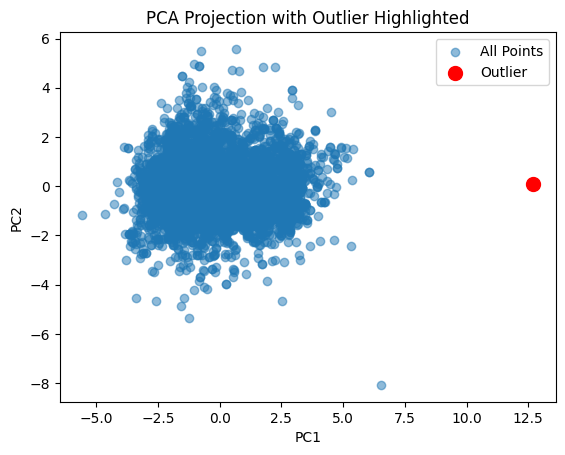

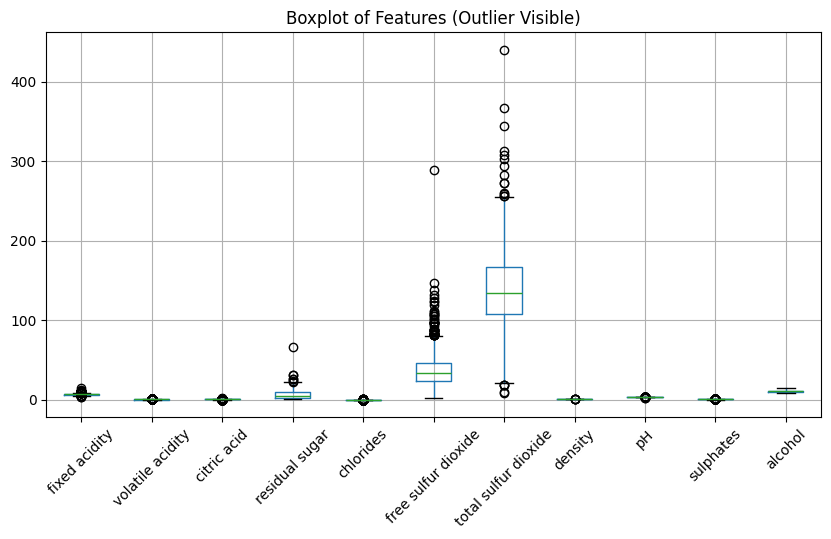

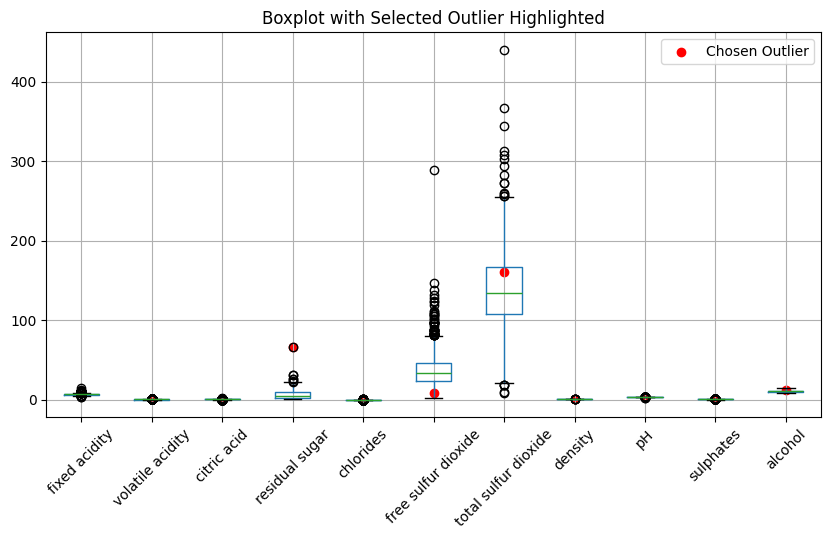

In [13]:
# YOUR CODE HERE

# Use first 2 principal components to compute distance from origin in PCA space
dist = np.sqrt(X_pca[:, 0]**2 + X_pca[:, 1]**2)

# Identify the outlier as the point with the largest distance
outlier_idx = np.argmax(dist)

# Retrieve the original row corresponding to the outlier
outlier_row = df_wine.iloc[outlier_idx]
print(outlier_row)

# Plot PCA projection and highlight the outlier
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, label="All Points")
plt.scatter(X_pca[outlier_idx, 0], X_pca[outlier_idx, 1],
            color='red', s=100, label="Outlier")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection with Outlier Highlighted")
plt.legend()
plt.show()

# Boxplot of all features to show where outlier stands
df_wine.drop(columns=["target"]).boxplot(figsize=(10, 5))
plt.title("Boxplot of Features (Outlier Visible)")
plt.xticks(rotation=45)
plt.show()

# Boxplot with outlier row highlighted
outlier_values = df_wine.drop(columns=["target"]).iloc[outlier_idx]

df_wine.drop(columns=["target"]).boxplot(figsize=(10, 5))
plt.scatter(range(1, len(outlier_values)+1), outlier_values,
            color='red', label="Chosen Outlier")
plt.xticks(rotation=45)
plt.legend()
plt.title("Boxplot with Selected Outlier Highlighted")
plt.show()

YOUR ANSWERS HERE

The criterion used to identify the outlier is the Euclidean distance from the origin in PCA space, using the first two principal components, which together explain about 72.8% of the total variance. The distance for each point is calculated as:
√(PC1² + PC2²)
The point with the largest distance is selected as the outlier. This method works well because PCA centers the data and projects it in the directions of most variation, so unusual points naturally end up far from the origin.
The identified outlier is row 2781, which has a residual sugar value of 65.8, far above the typical range of 1 to 15 in the dataset. This extreme value is likely what pushes it so far along PC1. The boxplot also confirms this, as the outlier point sits well above the rest of the data in the residual sugar column. The PCA plot shows it clearly separated from the main cluster, appearing far to the right while all other points remain grouped near the origin.